# 文件: chart_40_1.py

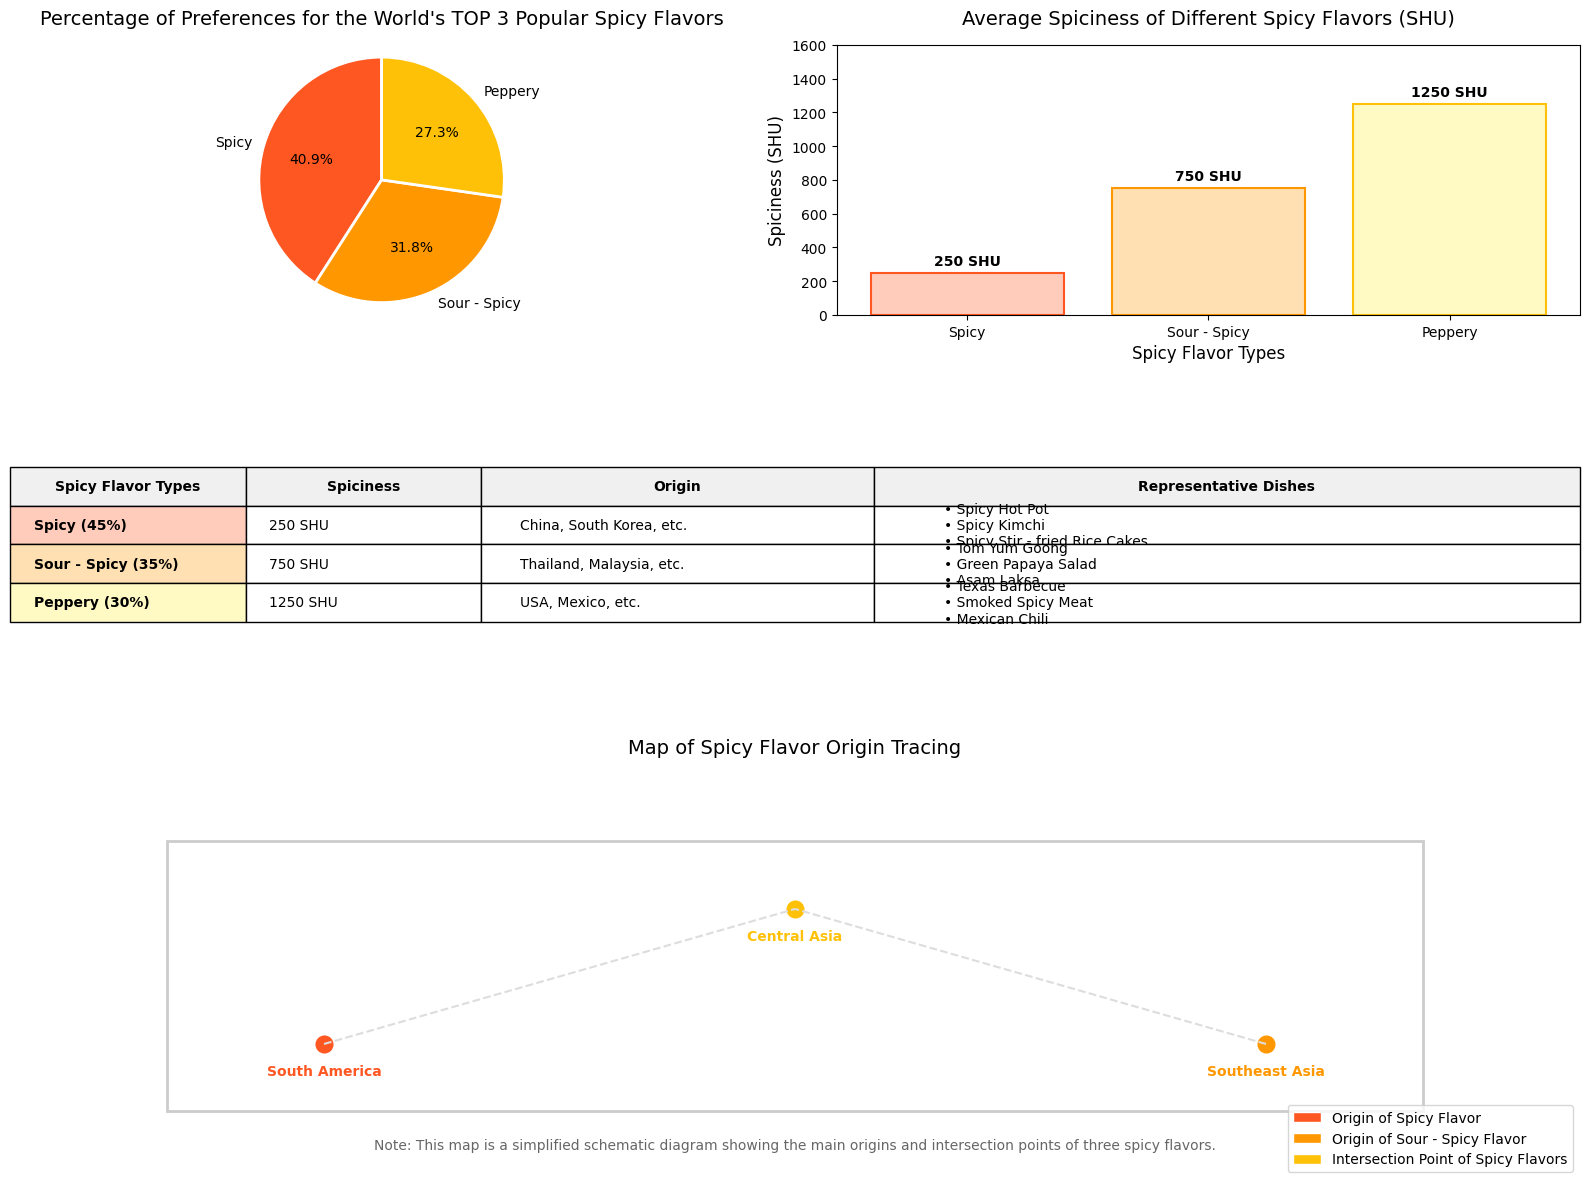

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch

# Data
spicy_types = ["Spicy", "Sour - Spicy", "Peppery"]
preference_percentages = [45, 35, 30]
scoville_units = [250, 750, 1250]  # Middle value of spiciness
origins = ["China, South Korea, etc.", "Thailand, Malaysia, etc.", "USA, Mexico, etc."]
representative_dishes = [
    ["Spicy Hot Pot", "Spicy Kimchi", "Spicy Stir - fried Rice Cakes"],
    ["Tom Yum Goong", "Green Papaya Salad", "Asam Laksa"],
    ["Texas Barbecue", "Smoked Spicy Meat", "Mexican Chili"]
]

# Color definition
colors = ['#FF5722', '#FF9800', '#FFC107']
light_colors = ['#FFCCBC', '#FFE0B2', '#FFF9C4']

# Create a canvas
fig = plt.figure(figsize=(16, 12))
gs = fig.add_gridspec(3, 2, height_ratios=[1, 1, 1.5])

# 1. Pie chart of preference percentages
ax1 = fig.add_subplot(gs[0, 0])
ax1.pie(preference_percentages, labels=spicy_types, autopct='%1.1f%%',
        startangle=90, colors=colors, wedgeprops={'edgecolor': 'w', 'linewidth': 2})
ax1.set_title('Percentage of Preferences for the World\'s TOP 3 Popular Spicy Flavors', fontsize=14, pad=15)
ax1.axis('equal')  # Ensure the pie chart is circular

# 2. Bar chart of spiciness comparison
ax2 = fig.add_subplot(gs[0, 1])
bars = ax2.bar(spicy_types, scoville_units, color=light_colors, edgecolor=colors, linewidth=1.5)
ax2.set_title('Average Spiciness of Different Spicy Flavors (SHU)', fontsize=14, pad=15)
ax2.set_xlabel('Spicy Flavor Types', fontsize=12)
ax2.set_ylabel('Spiciness (SHU)', fontsize=12)
ax2.set_ylim(0, 1600)

# Add numerical labels to each bar
for bar in bars:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 30,
             f'{height} SHU', ha='center', va='bottom', fontweight='bold')

# 3. Information table of spicy flavor types
ax3 = fig.add_subplot(gs[1, :])
ax3.axis('off')

# Table data
table_data = []
for i, (spicy_type, percentage, scoville, origin, dishes) in enumerate(zip(
    spicy_types, preference_percentages, scoville_units, origins, representative_dishes
)):
    table_data.append([
        f'{spicy_type} ({percentage}%)', 
        f'{scoville} SHU', 
        origin,
        '\n'.join([f'• {dish}' for dish in dishes])
    ])

# Create the table
table = ax3.table(
    cellText=table_data,
    colLabels=['Spicy Flavor Types', 'Spiciness', 'Origin', 'Representative Dishes'],
    loc='center',
    cellLoc='left',
    colWidths=[0.15, 0.15, 0.25, 0.45]
)

# Set table style
table.set_fontsize(12)
table.scale(1, 2)  # Adjust the table size

for i in range(len(spicy_types)):
    table[(i+1, 0)].set_facecolor(light_colors[i])
    table[(i+1, 0)].set_text_props(weight='bold', color='black')

for j in range(4):
    table[(0, j)].set_facecolor('#f0f0f0')
    table[(0, j)].set_text_props(weight='bold')

# 4. Simplified map of spicy flavor origin tracing
ax4 = fig.add_subplot(gs[2, :])
ax4.set_title('Map of Spicy Flavor Origin Tracing', fontsize=14, pad=15)
ax4.set_xlim(0, 10)
ax4.set_ylim(0, 6)
ax4.axis('off')

# Draw the simplified world map outline
world_map = plt.Rectangle((1, 1), 8, 4, fill=False, edgecolor='#CCCCCC', linewidth=2)
ax4.add_patch(world_map)

# Draw the origin and intersection points of spicy flavors
origin_points = [
    (2, 2, "South America", colors[0]),  # Origin of spicy flavor
    (8, 2, "Southeast Asia", colors[1]),  # Origin of sour - spicy flavor
    (5, 4, "Central Asia", colors[2])     # Intersection point of spicy flavors
]

# Add origin markers
for x, y, name, color in origin_points:
    ax4.plot(x, y, 'o', markersize=12, color=color)
    ax4.text(x, y-0.3, name, ha='center', va='top', fontweight='bold', color=color)

# Add connection lines
ax4.plot([2, 5], [2, 4], '--', color='#DDDDDD')
ax4.plot([8, 5], [2, 4], '--', color='#DDDDDD')

# Add legend
legend_elements = [
    Patch(facecolor=colors[0], edgecolor='w', label='Origin of Spicy Flavor'),
    Patch(facecolor=colors[1], edgecolor='w', label='Origin of Sour - Spicy Flavor'),
    Patch(facecolor=colors[2], edgecolor='w', label='Intersection Point of Spicy Flavors')
]
ax4.legend(handles=legend_elements, loc='lower right')

# Add descriptive text
ax4.text(5, 0.5, "Note: This map is a simplified schematic diagram showing the main origins and intersection points of three spicy flavors.", 
         ha='center', va='center', fontsize=10, color='#666666')

# Adjust the layout
plt.tight_layout()
plt.subplots_adjust(hspace=0.3)

# Display the chart
plt.show()

# 文件: chart_40_2.py

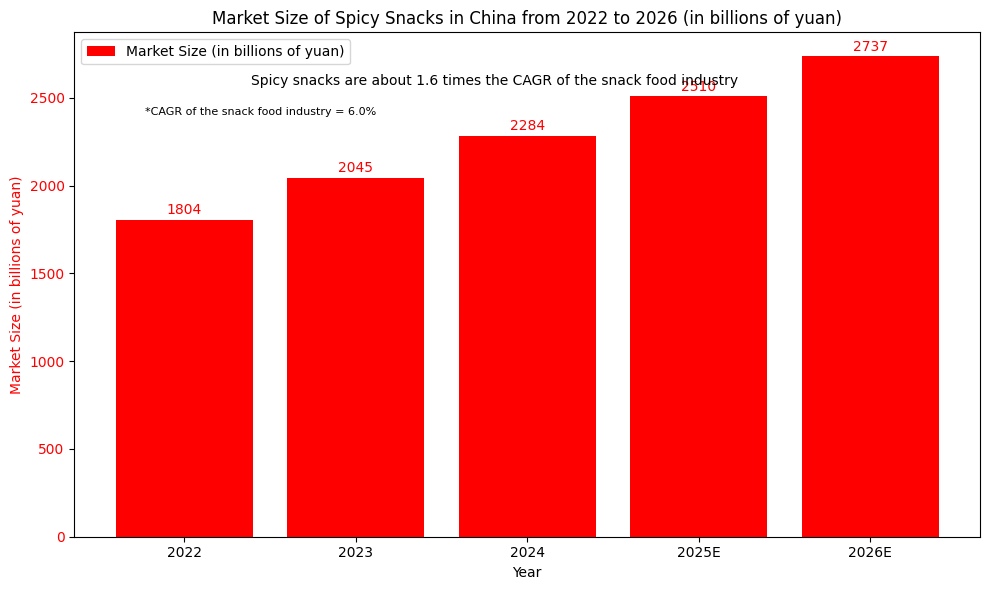

In [2]:
import matplotlib.pyplot as plt
import numpy as np

# Years
years = np.array([2022, 2023, 2024, 2025, 2026])
# Market size data (in billions of yuan), roughly simulating the trend of the original data
market_size = np.array([1804, 2045, 2284, 2510, 2737])

# Create a figure and set a reasonable size
fig, ax = plt.subplots(figsize=(10, 6))

# Draw a bar chart and save the returned container object
bars = ax.bar(years, market_size, color='r', label='Market Size (in billions of yuan)')
ax.set_xlabel('Year')
ax.set_ylabel('Market Size (in billions of yuan)', color='r')
ax.tick_params(axis='y', labelcolor='r')

# Set the x-axis tick marks to years
ax.set_xticks(years)

# Generate year labels with 'E'
year_labels = []
for year in years:
    if year in [2025, 2026]:
        year_labels.append(f"{year}E")  # Add 'E' for predicted years
    else:
        year_labels.append(str(year))   # Keep actual years unchanged

# Set year labels with 'E'
ax.set_xticklabels(year_labels)

# Label the value above each bar (without 'E')
for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2.,  # x-coordinate: center of the bar
        height + 15,  # y-coordinate: 15 units above the top of the bar
        f'{height}',  # Display the value
        ha='center',  # Horizontal center alignment
        va='bottom',  # Vertical bottom alignment
        color='r',    # Text color is the same as the bar
        fontsize=10   # Font size
    )

# Add a title
plt.title('Market Size of Spicy Snacks in China from 2022 to 2026 (in billions of yuan)')

# Use the fig.text() method to add annotations
fig.text(0.5, 0.85, 'Spicy snacks are about 1.6 times the CAGR of the snack food industry',
         ha='center', fontsize=10)

fig.text(0.15, 0.80, '*CAGR of the snack food industry = 6.0%', fontsize=8)

# Add a legend
ax.legend(loc='upper left')

# Adjust the layout
plt.tight_layout()
# Display the chart
plt.show()

# 文件: chart_40_3.py

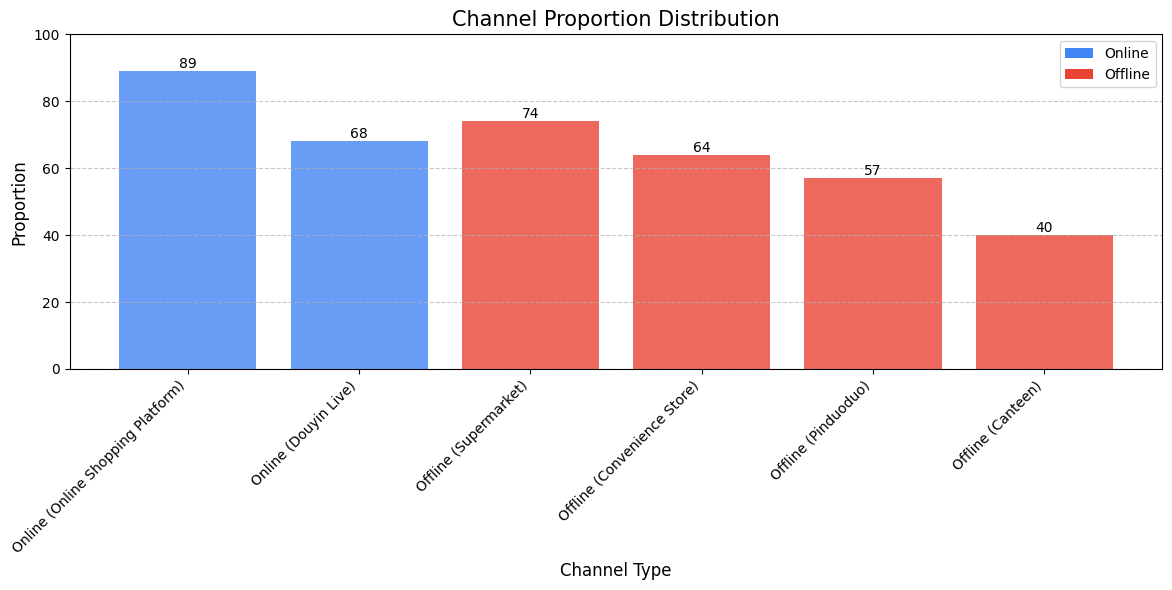

In [2]:
import matplotlib.pyplot as plt
import pandas as pd

# Build data
data = {
    'Channel': ['Online (Online Shopping Platform)', 'Online (Douyin Live)', 'Offline (Supermarket)', 'Offline (Convenience Store)', 'Offline (Pinduoduo)', 'Offline (Canteen)'],
    'Proportion': [89, 68, 74, 64, 57, 40]
}
df = pd.DataFrame(data)

# Create a canvas
plt.figure(figsize=(12, 6))

# Draw a bar chart
colors = ['#4285F4', '#4285F4', '#EA4335', '#EA4335', '#EA4335', '#EA4335']  # 区分线上(蓝色)和线下(红色)
bars = plt.bar(df['Channel'], df['Proportion'], color=colors, alpha=0.8)

# Add data labels
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height}',
             ha='center', va='bottom', fontsize=10)

# Set title and labels
plt.title('Channel Proportion Distribution', fontsize=15)
plt.xlabel('Channel Type', fontsize=12)
plt.ylabel('Proportion', fontsize=12)

# Set y-axis range
plt.ylim(0, 100)

# Rotate x-axis labels for better display
plt.xticks(rotation=45, ha='right')

# Add grid lines
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#4285F4', label='Online'),
                   Patch(facecolor='#EA4335', label='Offline')]
plt.legend(handles=legend_elements, loc='upper right')

# Optimize layout
plt.tight_layout()

# Show the plot
plt.show()

# 文件: chart_40_4.py

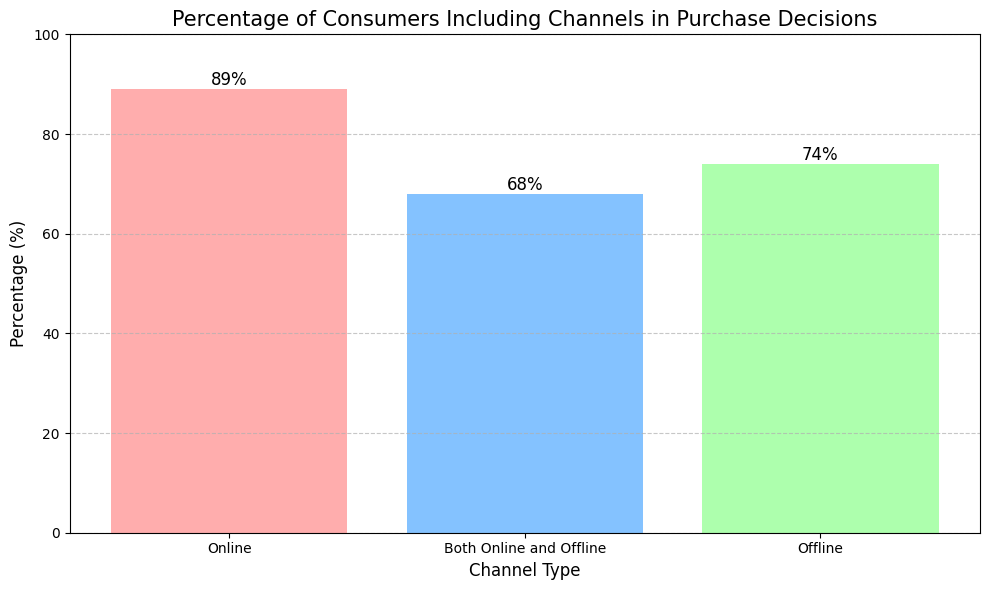

In [3]:
import matplotlib.pyplot as plt

# Data
channels = ['Online', 'Both Online and Offline', 'Offline']
percentages = [89, 68, 74]

# Create a canvas
plt.figure(figsize=(10, 6))

# Draw a bar chart
bars = plt.bar(channels, percentages, color=['#ff9999', '#66b3ff', '#99ff99'], alpha=0.8)

# Add data labels
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height}%',
             ha='center', va='bottom', fontsize=12)

# Set title and labels
plt.title('Percentage of Consumers Including Channels in Purchase Decisions', fontsize=15)
plt.xlabel('Channel Type', fontsize=12)
plt.ylabel('Percentage (%)', fontsize=12)

# Set y-axis range
plt.ylim(0, 100)

# Add grid lines
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Optimize layout
plt.tight_layout()

# Show the plot
plt.show()